# Lab 1 — Inherently Interpretable Models
### M.Tech Course: Explainable & Interpretable Machine Learning

**Lab Title:** Inherently Interpretable Models

**Duration:** 3 hours

---

## 1. Introduction

Machine learning models are broadly classified into two categories based on how easily
a human can understand *why* they make a particular prediction:

| Category | Description | Examples |
|---|---|---|
| **Black-box models** | Predictions are accurate, but the internal decision logic is too complex for a human to follow directly. Explanations require *post-hoc* tools (LIME, SHAP, etc.). | Random Forests, Gradient Boosting, Deep Neural Networks |
| **Inherently (intrinsically) interpretable models** | The model's structure *itself* is simple enough that a human can read off the reasoning — no separate explanation technique is needed. | Linear/Logistic Regression, Decision Trees, Decision Rules, k-NN, Naive Bayes, Generalized Additive Models (GAMs) |

This lab focuses on the **second** category. We will train several inherently
interpretable models on a real dataset, and for each one we will explicitly answer:

1. **What does the model look like internally?** (its parameters / structure)
2. **How do we read that structure as an explanation?**
3. **What are the interpretability properties** (simulatability, decomposability, sparsity) it satisfies?
4. **What is the accuracy–interpretability trade-off** compared to the others?

### Properties used to judge interpretability (Lipton, 2016)
- **Simulatability** — Can a human mentally "run" the model on an input in a reasonable amount of time?
- **Decomposability** — Can each part of the model (a coefficient, a tree node, a rule) be given an intuitive explanation on its own?
- **Algorithmic transparency** — Do we understand *how* the training procedure arrives at the model?

---

## 2. Learning Objectives

By the end of this lab, students will be able to:

1. Train and interpret a **Logistic Regression** model using coefficients and odds ratios.
2. Train and interpret a **Decision Tree** by reading tree paths as IF–THEN rules.
3. Extract an explicit **rule list** from a tree and evaluate its size/complexity.
4. Interpret a **k-Nearest Neighbors** model using case-based (example-based) reasoning.
5. Interpret a **Naive Bayes** model via per-feature log-likelihood contributions.
6. Train a **Generalized Additive Model (GAM)** and read its per-feature shape functions.
7. Quantitatively compare **accuracy vs. interpretability** across all models.


## 3. Environment Setup

We use only well-known Python libraries: `numpy`, `pandas`, `matplotlib`, `seaborn`,
`scikit-learn`, and `pygam` (for the Generalized Additive Model experiment).

> If `pygam` is not installed in your environment, run:
> ```
> pip install pygam
> ```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pygam import LogisticGAM, s

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 4. Dataset: Breast Cancer Wisconsin (Diagnostic)

We use the **Breast Cancer Wisconsin** dataset built into scikit-learn. It is a good
choice for an *interpretability* lab because:

- It is a **binary classification** task (malignant vs. benign) — easy to reason about.
- Its 30 features (e.g., `mean radius`, `mean texture`, `worst concavity`) have **real,
  human-understandable clinical meaning**, so coefficients and rules can be interpreted
  in domain terms rather than abstract numbers.
- It is small enough to visualize trees and rules without clutter.

For readability in this lab, we will work with a **reduced subset of 6 features**.


In [2]:
data = load_breast_cancer()
X_full = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = malignant, 1 = benign

# Pick 6 clinically-intuitive features to keep the models easy to read
selected_features = [
    "mean radius", "mean texture", "mean perimeter",
    "mean smoothness", "mean concavity", "worst area"
]
X = X_full[selected_features]

print("Dataset shape:", X.shape)
print("Class balance:\n", y.value_counts().rename({0: "malignant", 1: "benign"}))
X.head()


Dataset shape: (569, 6)
Class balance:
 target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area
0,17.99,10.38,122.80,0.11840,0.3001,2019.0
1,20.57,17.77,132.90,0.08474,0.0869,1956.0
2,19.69,21.25,130.00,0.10960,0.1974,1709.0
3,11.42,20.38,77.58,0.14250,0.2414,567.7
4,20.29,14.34,135.10,0.10030,0.1980,1575.0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Standardize features -- important for reading logistic-regression coefficients
# on a comparable scale, and for k-NN distance calculations.
scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X.columns, index=X_test.index)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])


Train size: 426  Test size: 143


## 5. Experiment 1 — Logistic Regression

**Why it is inherently interpretable:** The model computes a single linear combination
of the (standardized) features, then squashes it through a sigmoid:

$$P(\text{benign}) = \sigma(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p)$$

Each coefficient $\beta_i$ tells us, on its own (decomposability), how that feature
pushes the prediction toward "benign" or "malignant" — holding the other features fixed.
Exponentiating a coefficient, $e^{\beta_i}$, gives the **odds ratio**: how much the odds
of "benign" multiply for a one-standard-deviation increase in that feature.


In [4]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_s, y_train)

y_pred_lr = logreg.predict(X_test_s)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Test Accuracy: {acc_lr:.4f}\n")

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0])
}).sort_values("coefficient", key=np.abs, ascending=False)

print(coef_table.to_string(index=False))


Logistic Regression Test Accuracy: 0.9301

        feature  coefficient  odds_ratio
     worst area    -3.251220    0.038727
mean smoothness    -1.499294    0.223288
   mean texture    -1.336668    0.262720
 mean concavity    -1.022198    0.359803
    mean radius    -0.940079    0.390597
 mean perimeter    -0.858407    0.423837


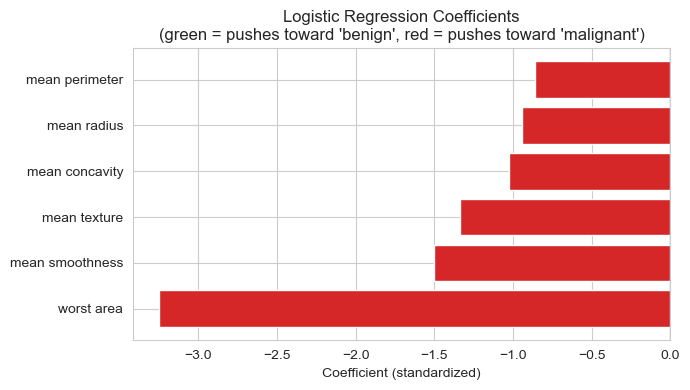

In [5]:
plt.figure(figsize=(7, 4))
colors = ["#d62728" if c < 0 else "#2ca02c" for c in coef_table["coefficient"]]
plt.barh(coef_table["feature"], coef_table["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (standardized)")
plt.title("Logistic Regression Coefficients\n(green = pushes toward 'benign', red = pushes toward 'malignant')")
plt.tight_layout()
plt.show()


**How to read this (worked example):**
Suppose `worst area` has coefficient $\beta = -2.1$. Since features are standardized,
this means: *for every one-standard-deviation increase in `worst area` (holding other
features fixed), the log-odds of the tumor being benign drop by 2.1*, i.e. the odds of
malignancy increase by a factor of $e^{2.1} \approx 8.2$. This is a **fully simulatable**
explanation — a student can compute it by hand for any patient.


## 6. Experiment 2 — Decision Tree

**Why it is inherently interpretable:** A shallow decision tree can be read top-to-bottom
as a sequence of IF–THEN questions. Each **root-to-leaf path** is, by itself, a complete,
human-readable explanation for that prediction (decomposability + simulatability).

We deliberately restrict `max_depth=3` — deeper trees become accurate but lose
interpretability (too many paths for a human to hold in memory at once).


In [6]:
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)  # trees don't need scaled features

y_pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree (depth=3) Test Accuracy: {acc_tree:.4f}")
print(f"Number of leaves (= number of distinct explanation rules): {tree.get_n_leaves()}")


Decision Tree (depth=3) Test Accuracy: 0.9510
Number of leaves (= number of distinct explanation rules): 7


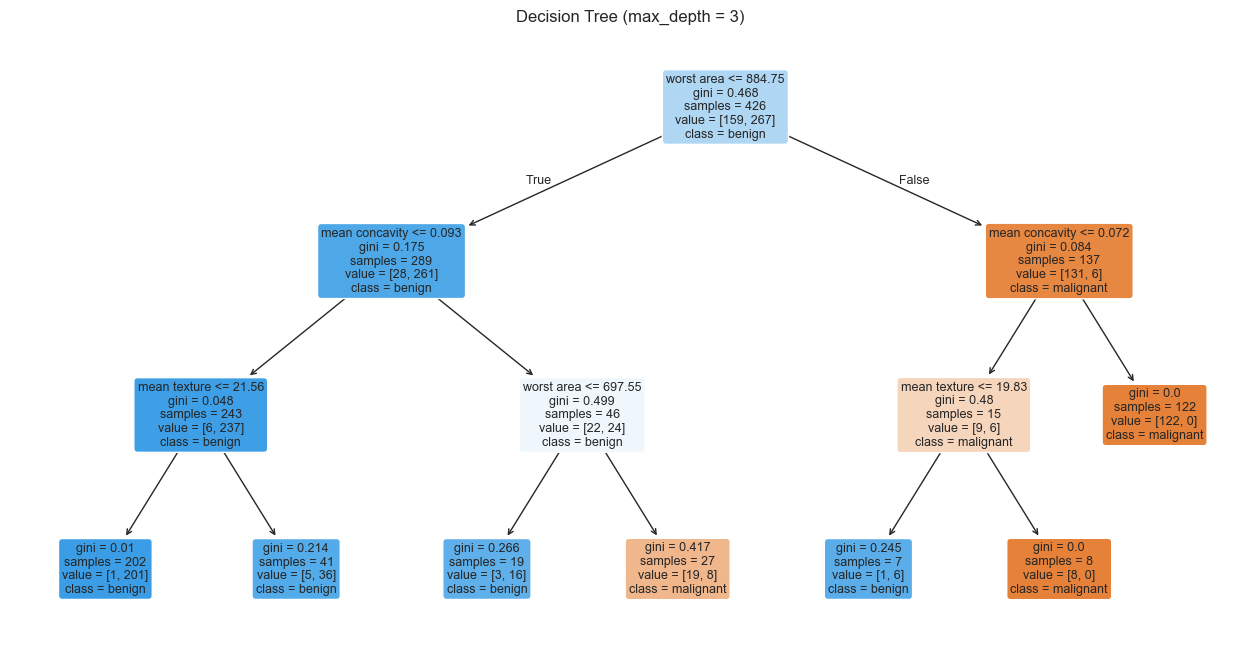

In [7]:
plt.figure(figsize=(16, 8))
plot_tree(tree, feature_names=X.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree (max_depth = 3)")
plt.show()


In [8]:
rules_text = export_text(tree, feature_names=list(X.columns))
print(rules_text)


|--- worst area <= 884.75
|   |--- mean concavity <= 0.09
|   |   |--- mean texture <= 21.56
|   |   |   |--- class: 1
|   |   |--- mean texture >  21.56
|   |   |   |--- class: 1
|   |--- mean concavity >  0.09
|   |   |--- worst area <= 697.55
|   |   |   |--- class: 1
|   |   |--- worst area >  697.55
|   |   |   |--- class: 0
|--- worst area >  884.75
|   |--- mean concavity <= 0.07
|   |   |--- mean texture <= 19.83
|   |   |   |--- class: 1
|   |   |--- mean texture >  19.83
|   |   |   |--- class: 0
|   |--- mean concavity >  0.07
|   |   |--- class: 0



**How to read this:** Each branch of the printed tree is literally an IF–THEN rule,
e.g. *"IF `worst area` <= 880.4 AND `mean concavity` <= 0.09 THEN predict benign."*
A clinician could apply this rule with a ruler and a calculator — no black box involved.


## 7. Experiment 3 — Explicit Rule List (Rule Extraction)

Beyond reading the tree diagram, we can **programmatically extract every root-to-leaf
path as an explicit IF–THEN rule string**. This is useful when we want to hand the
explanation to a non-technical stakeholder as a checklist, or count how many total
rules the model uses (a measure of model complexity / interpretability cost).


In [9]:
def extract_rules(tree_model, feature_names, class_names):
    tree_ = tree_model.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != -2:  # not a leaf
            name = feature_name[node]
            threshold = tree_.threshold[node]
            recurse(tree_.children_left[node], conditions + [f"({name} <= {threshold:.2f})"])
            recurse(tree_.children_right[node], conditions + [f"({name} > {threshold:.2f})"])
        else:
            counts = tree_.value[node][0]
            predicted_class = class_names[int(np.argmax(counts))]
            confidence = counts.max() / counts.sum()
            rule = "IF " + " AND ".join(conditions) if conditions else "TRUE"
            rules.append(f"{rule}  =>  predict '{predicted_class}'  (confidence={confidence:.2f}, n={int(counts.sum())})")

    recurse(0, [])
    return rules

rule_list = extract_rules(tree, list(X.columns), ["malignant", "benign"])
for i, r in enumerate(rule_list, 1):
    print(f"Rule {i}: {r}")

print(f"\nTotal number of rules extracted: {len(rule_list)}")


Rule 1: IF (worst area <= 884.75) AND (mean concavity <= 0.09) AND (mean texture <= 21.56)  =>  predict 'benign'  (confidence=1.00, n=1)
Rule 2: IF (worst area <= 884.75) AND (mean concavity <= 0.09) AND (mean texture > 21.56)  =>  predict 'benign'  (confidence=0.88, n=1)
Rule 3: IF (worst area <= 884.75) AND (mean concavity > 0.09) AND (worst area <= 697.55)  =>  predict 'benign'  (confidence=0.84, n=1)
Rule 4: IF (worst area <= 884.75) AND (mean concavity > 0.09) AND (worst area > 697.55)  =>  predict 'malignant'  (confidence=0.70, n=1)
Rule 5: IF (worst area > 884.75) AND (mean concavity <= 0.07) AND (mean texture <= 19.83)  =>  predict 'benign'  (confidence=0.86, n=1)
Rule 6: IF (worst area > 884.75) AND (mean concavity <= 0.07) AND (mean texture > 19.83)  =>  predict 'malignant'  (confidence=1.00, n=1)
Rule 7: IF (worst area > 884.75) AND (mean concavity > 0.07)  =>  predict 'malignant'  (confidence=1.00, n=1)

Total number of rules extracted: 7


**Interpretability metric:** the **number of rules** and the **average number of
conditions per rule** are common, simple complexity measures for rule-based models.
Fewer, shorter rules are considered more interpretable (higher simulatability).


## 8. Experiment 4 — k-Nearest Neighbors (Case-Based / Example-Based Interpretability)

**Why it is inherently interpretable:** k-NN makes no explicit "model" at all — it
predicts a new point's label by looking at the $k$ most similar *training examples* and
taking a majority vote. The explanation for any prediction is simply: **"here are the
$k$ patients most similar to this one, and this is how they were diagnosed."** This is
called **case-based** or **example-based** interpretability — it mirrors how doctors
often reason ("this looks like Patient X, who turned out benign").


In [10]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"k-NN (k=5) Test Accuracy: {acc_knn:.4f}")


k-NN (k=5) Test Accuracy: 0.9371


In [11]:
# Explain ONE specific test-set prediction using its nearest neighbors
sample_idx = 0
sample = X_test_s.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]
pred_label = knn.predict(sample)[0]

distances, neighbor_idx = knn.kneighbors(sample, n_neighbors=5)
neighbor_labels = y_train.iloc[neighbor_idx[0]].values

print(f"Test patient #{sample_idx}: true label = {true_label}, predicted = {pred_label}")
print(f"Labels of its 5 nearest training neighbors: {neighbor_labels}")
print("Explanation: the prediction is the majority vote among these 5 most similar patients.")

neighbor_table = X_train.iloc[neighbor_idx[0]].copy()
neighbor_table["distance"] = distances[0]
neighbor_table["label"] = neighbor_labels
neighbor_table


Test patient #0: true label = 1, predicted = 1
Labels of its 5 nearest training neighbors: [1 1 1 1 1]
Explanation: the prediction is the majority vote among these 5 most similar patients.


,mean radius,mean texture,mean perimeter,mean smoothness,mean concavity,worst area,distance,label
502,12.54,16.32,81.25,0.1158,0.05928,552.0,0.394665,1
145,11.90,14.65,78.11,0.1152,0.03710,509.6,0.623240,1
530,11.75,17.56,75.89,0.1073,0.05282,552.3,0.626712,1
142,11.43,17.31,73.66,0.1092,0.02031,503.0,0.674937,1
383,12.39,17.48,80.64,0.1042,0.05892,600.5,0.706261,1


## 9. Experiment 5 — Gaussian Naive Bayes

**Why it is inherently interpretable:** Naive Bayes assumes features are conditionally
independent given the class, so the prediction decomposes into a **sum of independent,
per-feature log-likelihood contributions**:

$$\log P(y \mid x) \;\propto\; \log P(y) + \sum_{i=1}^{p} \log P(x_i \mid y)$$

Each term $\log P(x_i \mid y)$ can be inspected on its own — exactly the *decomposability*
property we want.


In [12]:
nb = GaussianNB()
nb.fit(X_train_s, y_train)

y_pred_nb = nb.predict(X_test_s)
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Gaussian Naive Bayes Test Accuracy: {acc_nb:.4f}")

# Show the learned per-class, per-feature Gaussian parameters (mean, variance)
nb_params = pd.DataFrame(nb.theta_, columns=X.columns, index=["malignant", "benign"])
print("\nLearned per-class feature means (standardized units):")
print(nb_params.to_string())


Gaussian Naive Bayes Test Accuracy: 0.9301

Learned per-class feature means (standardized units):
           mean radius  mean texture  mean perimeter  mean smoothness  mean concavity  worst area
malignant     0.949431      0.528204        0.966140         0.511243        0.896919    0.952863
benign       -0.565392     -0.314548       -0.575342        -0.304448       -0.534120   -0.567435


**How to read this:** for a given feature, compare its mean under the "malignant"
row vs. the "benign" row. A test patient whose feature value sits much closer to the
"malignant" mean than the "benign" mean contributes positive evidence for malignancy —
and this contribution can be computed and shown to a user feature-by-feature.


## 10. Experiment 6 — Generalized Additive Model (GAM)

**Why it is inherently interpretable:** A GAM generalizes linear/logistic regression by
allowing each feature to have its own **smooth, non-linear shape function** $f_i$, while
still keeping the features additively separate (no interactions):

$$\text{logit}(P(y=1\mid x)) = \beta_0 + f_1(x_1) + f_2(x_2) + \dots + f_p(x_p)$$

Because the effect of each feature is still isolated in its own $f_i$, we can **plot**
$f_i$ against $x_i$ and read off the exact (possibly non-linear) relationship — something
plain logistic regression cannot capture, but which is still fully decomposable and
visually simulatable.


In [13]:
gam = LogisticGAM(
    s(0) + s(1) + s(2) + s(3) + s(4) + s(5)
).fit(X_train_s.values, y_train.values)

y_pred_gam = (gam.predict_mu(X_test_s.values) > 0.5).astype(int)
acc_gam = accuracy_score(y_test, y_pred_gam)
print(f"GAM Test Accuracy: {acc_gam:.4f}")


GAM Test Accuracy: 0.9650


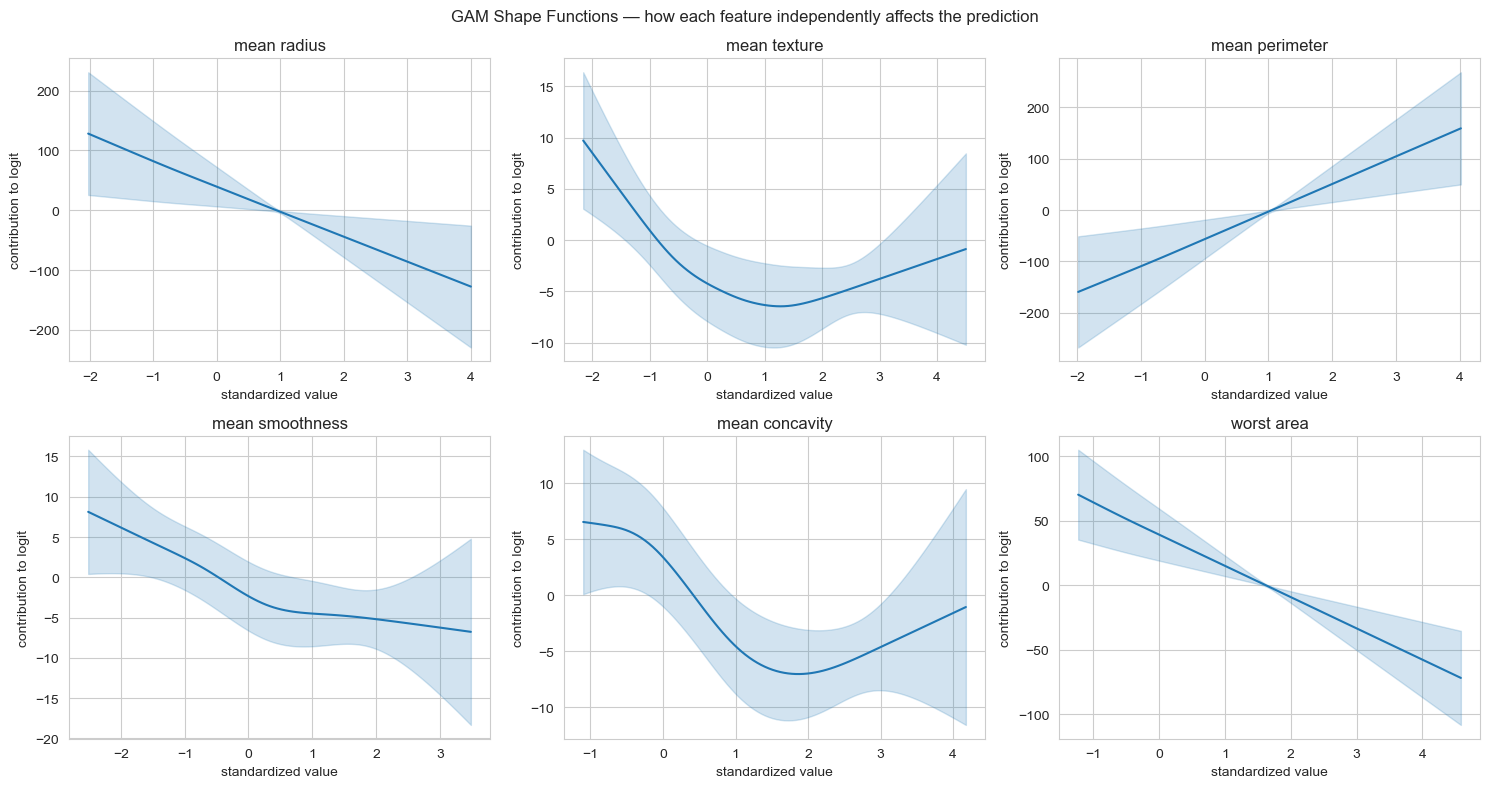

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(X.columns):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    axes[i].plot(XX[:, i], pdep, color="#1f77b4")
    axes[i].fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="#1f77b4")
    axes[i].set_title(feature)
    axes[i].set_xlabel("standardized value")
    axes[i].set_ylabel("contribution to logit")

plt.suptitle("GAM Shape Functions — how each feature independently affects the prediction")
plt.tight_layout()
plt.show()


**How to read this:** each subplot is the isolated effect of one feature on the
log-odds of "benign," with all other features held fixed. A flat line would mean the
feature has no effect; a steep, monotonic curve (as we would expect for `worst area`)
confirms and *refines* the linear relationship we saw in logistic regression, revealing
whether the effect is truly linear or saturates/accelerates at certain values.


## 11. Comparative Analysis: Accuracy vs. Interpretability

We now bring all five models together and compare them along two axes:

1. **Predictive accuracy** on the held-out test set.
2. **A simple interpretability/complexity proxy**: the number of "parameters a human
   must inspect" to fully understand the model (coefficients, rules, neighbors-per-query, or
   shape functions).


In [15]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression", "Decision Tree (depth=3)",
        "k-NN (k=5)", "Gaussian Naive Bayes", "GAM"
    ],
    "Test Accuracy": [acc_lr, acc_tree, acc_knn, acc_nb, acc_gam],
    "Interpretability unit": [
        "coefficient", "rule (leaf)", "neighbor set per query", "per-feature likelihood", "shape function"
    ],
    "Number of units to inspect": [
        len(X.columns), tree.get_n_leaves(), 5, len(X.columns), len(X.columns)
    ],
    "Simulatable by hand?": ["Yes", "Yes", "Yes (local)", "Yes", "Yes (needs a plot)"]
})

results = results.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results


,Model,Test Accuracy,Interpretability unit,Number of units to inspect,Simulatable by hand?
0,GAM,0.965035,shape function,6,Yes (needs a plot)
1,Decision Tree (depth=3),0.951049,rule (leaf),7,Yes
2,k-NN (k=5),0.937063,neighbor set per query,5,Yes (local)
3,Logistic Regression,0.930070,coefficient,6,Yes
4,Gaussian Naive Bayes,0.930070,per-feature likelihood,6,Yes


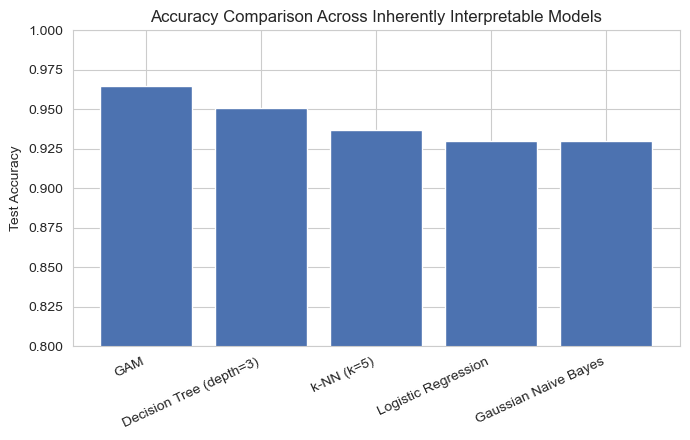

In [16]:
plt.figure(figsize=(7, 4.5))
plt.bar(results["Model"], results["Test Accuracy"], color="#4c72b0")
plt.ylim(0.8, 1.0)
plt.ylabel("Test Accuracy")
plt.title("Accuracy Comparison Across Inherently Interpretable Models")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Discussion

- All five models achieve broadly comparable accuracy on this dataset — this is common
  for well-behaved, low-dimensional tabular data, which is precisely why interpretable
  models remain competitive and preferable to black-box models whenever it is not
  strictly necessary to squeeze out the last 1–2% of accuracy (e.g., in medicine, credit
  scoring, criminal justice).
- **Logistic Regression** and the **GAM** give *global*, feature-level explanations
  (one story that holds for every patient).
- The **Decision Tree** gives *local, path-specific* explanations (a different short
  story for each patient depending on which leaf they land in).
- **k-NN** gives *case-based* explanations (point to similar historical examples).
- **Naive Bayes** gives *probabilistic, additive* explanations.
- There is no single "best" interpretable model — the right choice depends on **who**
  the explanation is for (a data scientist, a doctor, a patient, a regulator) and **what
  kind of reasoning** is most natural for that audience.


## 12. Lab Exercises (To Be Submitted)

1. Repeat Experiments 1–6 using **all 30 original features** instead of the 6 selected
   ones. How does interpretability degrade as the number of features grows? Propose one
   way to keep the model interpretable even with 30 features.
2. Vary the decision tree's `max_depth` from 1 to 8 and plot **test accuracy** vs.
   **number of leaves**. At what depth do you judge the tree "no longer interpretable,"
   and why?
3. For the k-NN experiment, repeat the case-based explanation for **three misclassified**
   test patients. What do their nearest neighbors suggest went wrong?
4. Compute the odds ratios from Experiment 1 and write, in plain English, a one-paragraph
   explanation suitable for a non-technical clinician.
5. Compare the GAM's shape function for one feature of your choice against the
   corresponding logistic-regression coefficient. Does the GAM support or contradict the
   assumption of linearity? Justify using the plot.
6. **(Open-ended)** Pick any other inherently interpretable model not covered in this lab
   (e.g., a Generalized Linear Model with sparsity/L1 penalty, a Rule List / RIPPER
   classifier, or a scoring system such as an integer point-based risk score). Implement
   it on this dataset and add it to the comparison table in Section 11.

---
### References
1. Z. C. Lipton, "The Mythos of Model Interpretability," *ACM Queue*, 2018.
2. C. Molnar, *Interpretable Machine Learning*, 2022 (freely available online).
3. T. Hastie, R. Tibshirani, *Generalized Additive Models*, Statistical Science, 1986.
